# Smart Quality Monitoring & Analytics System

This project visualizes manufacturing quality metrics through a Tableau dashboard powered by a dual-mode data pipeline. Users can operate in manual mode (CSV import) or automatic mode (Python-generated data).

### Import necessary libraries

In [827]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading CSV file

In [828]:
df_manufacturing = pd.read_csv('manufacturing-quality-control-dataset.csv')
df_manufacturing.head(100)

,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,defect_severity,defect_count,rework_required,comments,factory_location
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01T15:22:17,INS-2231,99.7,NaN,NaN,0,False,No issues detected. Batch meets all quality be...,Factory-E1
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02T09:18:43,INS-9052,87.4,NaN,NaN,0,False,Perfect batch. No defects observed.,Factory-Y7
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04T00:43:11,INS-0342,81.1,scratch,1.0,1,False,Minor scratch detected but within tolerance.,Factory-Z3
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03T16:08:29,INS-5961,94.3,NaN,NaN,0,False,Batch exceeded benchmarks.,Factory-X0
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04T08:42:14,INS-9052,77.8,marking,2.0,2,False,Spot marking observed. No rework required.,Factory-G9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,T2064-20240615,2024-06-15,PRD-02,morning,OP-0001,INSP-20046,2024-06-15T09:58:00,INS-1004,96.6,NaN,NaN,0,False,Batch meets all specifications. No defects.,Factory-E1
96,U3078-20240616,2024-06-16,PRD-03,afternoon,OP-7777,INSP-20047,2024-06-16T16:02:00,INS-1005,77.7,foreign_object,2.0,2,False,Foreign object found. Batch passes inspection.,Factory-A2
97,V4089-20240616,2024-06-16,PRD-04,night,OP-2517,INSP-20048,2024-06-17T02:18:00,INS-1006,52.7,mislabel,3.0,7,True,"Mislabel detected, batch failed and rework nee...",Factory-G9
98,W5097-20240616,2024-06-16,PRD-01,morning,OP-4178,INSP-20049,2024-06-16T08:26:00,INS-1007,100.0,NaN,NaN,0,False,Batch flawless. No issues detected.,Factory-E1


ensure dates are parsed and create useful columns like date, hour, shift

In [829]:

df = df_manufacturing.copy()

# parse date columns if present
for c in ['production_date', 'inspection_date']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

# create safe columns for time-based grouping
if 'production_date' in df.columns:
    df['prod_date'] = df['production_date'].dt.date
    df['prod_hour'] = df['production_date'].dt.hour
    df['prod_weekday'] = df['production_date'].dt.day_name()
    
# quick view
print("Rows,Cols:", df.shape)
display(df.head())
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False).head(20))


Rows,Cols: (200, 18)


,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,defect_severity,defect_count,rework_required,comments,factory_location,prod_date,prod_hour,prod_weekday
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01 15:22:17,INS-2231,99.7,NaN,NaN,0,False,No issues detected. Batch meets all quality be...,Factory-E1,2024-06-01,0,Saturday
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02 09:18:43,INS-9052,87.4,NaN,NaN,0,False,Perfect batch. No defects observed.,Factory-Y7,2024-06-02,0,Sunday
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04 00:43:11,INS-0342,81.1,scratch,1.0,1,False,Minor scratch detected but within tolerance.,Factory-Z3,2024-06-03,0,Monday
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03 16:08:29,INS-5961,94.3,NaN,NaN,0,False,Batch exceeded benchmarks.,Factory-X0,2024-06-03,0,Monday
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04 08:42:14,INS-9052,77.8,marking,2.0,2,False,Spot marking observed. No rework required.,Factory-G9,2024-06-04,0,Tuesday



Missing values per column:
 defect_type         89
defect_severity     89
production_date      0
prod_hour            0
prod_date            0
factory_location     0
comments             0
rework_required      0
defect_count         0
batch_id             0
quality_score        0
inspector_id         0
inspection_date      0
inspection_id        0
operator_id          0
shift                0
product_code         0
prod_weekday         0
dtype: int64


In [830]:
df.isnull().sum()   

batch_id             0
production_date      0
product_code         0
shift                0
operator_id          0
inspection_id        0
inspection_date      0
inspector_id         0
quality_score        0
defect_type         89
defect_severity     89
defect_count         0
rework_required      0
comments             0
factory_location     0
prod_date            0
prod_hour            0
prod_weekday         0
dtype: int64

### Data Cleaning and preprocessing 

In [831]:
df

,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,defect_severity,defect_count,rework_required,comments,factory_location,prod_date,prod_hour,prod_weekday
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01 15:22:17,INS-2231,99.7,NaN,NaN,0,False,No issues detected. Batch meets all quality be...,Factory-E1,2024-06-01,0,Saturday
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02 09:18:43,INS-9052,87.4,NaN,NaN,0,False,Perfect batch. No defects observed.,Factory-Y7,2024-06-02,0,Sunday
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04 00:43:11,INS-0342,81.1,scratch,1.0,1,False,Minor scratch detected but within tolerance.,Factory-Z3,2024-06-03,0,Monday
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03 16:08:29,INS-5961,94.3,NaN,NaN,0,False,Batch exceeded benchmarks.,Factory-X0,2024-06-03,0,Monday
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04 08:42:14,INS-9052,77.8,marking,2.0,2,False,Spot marking observed. No rework required.,Factory-G9,2024-06-04,0,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,T8452-20240624,2024-06-24,PRD-04,morning,OP-2186,INSP-0046,2024-06-24 08:55:00,INS-2517,97.5,NaN,NaN,0,False,No defects found during inspection.,Factory-Y7,2024-06-24,0,Monday
196,U3917-20240624,2024-06-24,PRD-01,afternoon,OP-7777,INSP-0047,2024-06-24 15:23:00,INS-0112,76.9,dent,2.0,1,False,"Minor dent found, batch passes.",Factory-X0,2024-06-24,0,Monday
197,V8093-20240625,2024-06-25,PRD-03,night,OP-1674,INSP-0048,2024-06-26 00:03:00,INS-3452,47.5,contamination,3.0,6,True,Batch failed due to contamination.,Factory-G9,2024-06-25,0,Tuesday
198,W5076-20240625,2024-06-25,PRD-02,afternoon,OP-5691,INSP-0049,2024-06-25 14:57:00,INS-5648,98.2,NaN,NaN,0,False,Batch PRD-02 meets all benchmarks.,Factory-E1,2024-06-25,0,Tuesday


In [832]:
df.isnull().sum()

batch_id             0
production_date      0
product_code         0
shift                0
operator_id          0
inspection_id        0
inspection_date      0
inspector_id         0
quality_score        0
defect_type         89
defect_severity     89
defect_count         0
rework_required      0
comments             0
factory_location     0
prod_date            0
prod_hour            0
prod_weekday         0
dtype: int64

In [833]:
df.describe()

,production_date,inspection_date,quality_score,defect_severity,defect_count,prod_hour
count,200,200,200.000000,111.000000,200.000,200.0
mean,2024-06-05 06:14:24,2024-06-05 22:22:56.749999872,75.699400,2.612613,3.225,0.0
min,2023-02-28 00:00:00,2023-03-01 01:18:49,0.000000,1.000000,0.000,0.0
25%,2024-06-04 00:00:00,2024-06-04 22:05:09,63.600000,2.000000,0.000,0.0
50%,2024-06-07 00:00:00,2024-06-07 10:28:22,81.150000,3.000000,1.000,0.0
75%,2024-06-14 00:00:00,2024-06-14 10:10:38.249999872,96.225000,4.000000,5.000,0.0
max,2024-06-30 00:00:00,2024-07-01 02:37:55,100.000000,4.000000,20.000,0.0
std,NaN,NaN,25.157249,1.113317,5.025,0.0


In [834]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering

In [835]:
# Create a time gap between production and inspection
df['inspection_delay'] = (df['inspection_date'] - df['production_date']).dt.days

# Flag severe defects
df['is_severe'] = np.where(df['defect_severity'].isin(['High', 'Critical']), 1, 0)


### EDA

Text(0.5, 1.0, 'Distribution of Quality Scores')

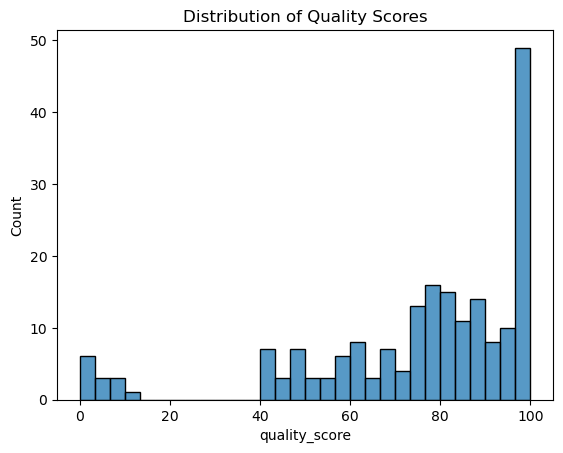

In [836]:
# Quality score distribution
sns.histplot(df['quality_score'], bins=30)
plt.title("Distribution of Quality Scores")


Text(0.5, 1.0, 'Defect Severity Distribution')

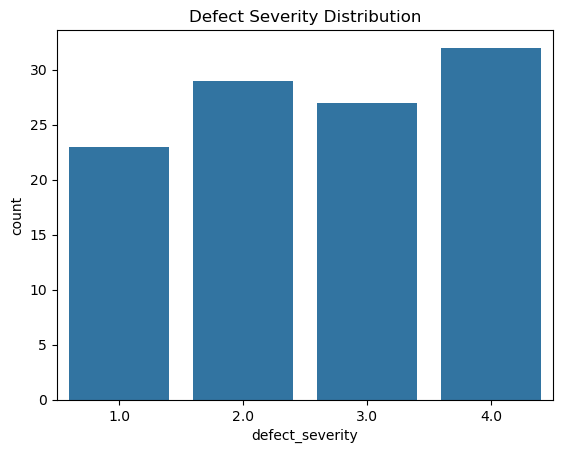

In [837]:

# Defect severity count
sns.countplot(x='defect_severity', data=df)
plt.title("Defect Severity Distribution")


Text(0.5, 1.0, 'Quality Score by Shift')

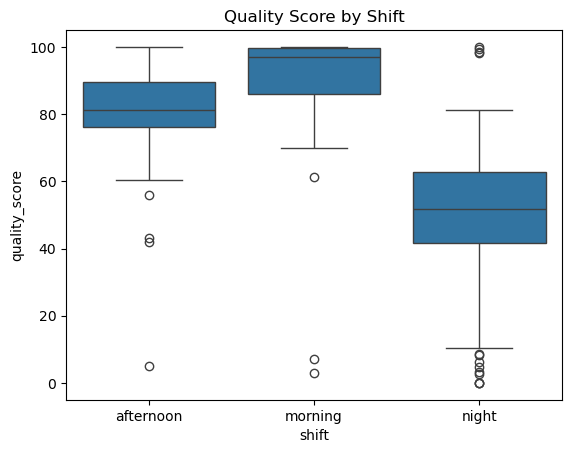

In [838]:
# Quality score by shift
sns.boxplot(x='shift', y='quality_score', data=df)
plt.title("Quality Score by Shift")



### Boxplot after Removing Outlier

/var/folders/tj/8m4f2hl545d85f9bhjg24z500000gn/T/ipykernel_55528/235222131.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




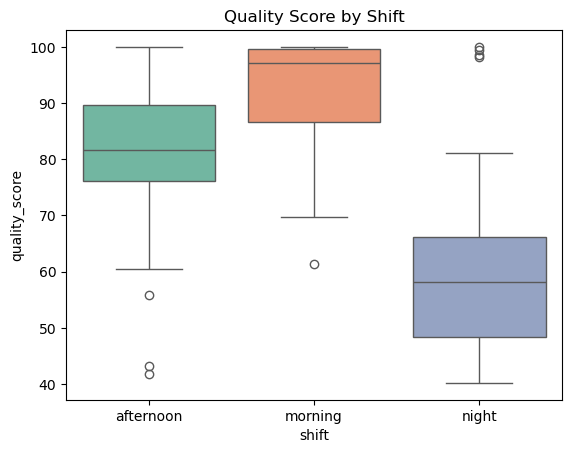

In [841]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'quality_score'
Q1 = df['quality_score'].quantile(0.25)
Q3 = df['quality_score'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_no_outliers = df[(df['quality_score'] >= lower_bound) & (df['quality_score'] <= upper_bound)]

# Plot without outliers
sns.boxplot(x='shift', y='quality_score', data=df_no_outliers, palette="Set2")
plt.title("Quality Score by Shift")
plt.show()


Text(0.5, 1.0, 'Defect Count vs Quality Score')

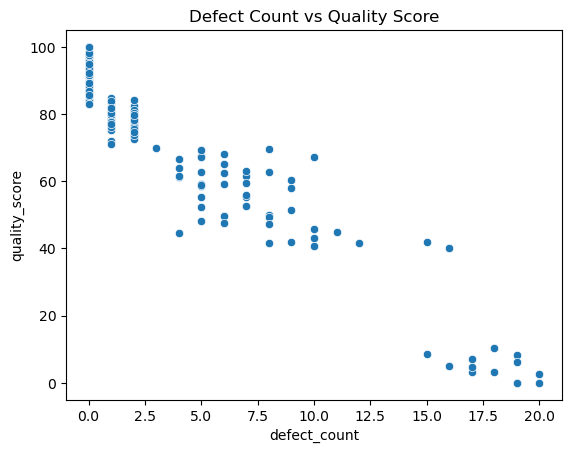

In [ ]:
# Defect count vs Quality Score
sns.scatterplot(x='defect_count', y='quality_score', data=df)
plt.title("Defect Count vs Quality Score")

In [ ]:
# Average defects per inspector
inspector_summary = df.groupby('inspector_id')['defect_count'].mean().sort_values(ascending=False)
inspector_summary.head(10)

inspector_id
INS-0342    10.000000
INS-1003     7.833333
INS-1006     7.142857
INS-4178     6.500000
INS-1009     6.000000
INS-1008     5.500000
INS-5467     5.090909
INS-8921     4.428571
INS-7741     3.928571
INS-1005     3.428571
Name: defect_count, dtype: float64

### Corelation Heatmap

In [ ]:
# import pandas as pd
# import seaborn as sns
# import numpy as np
# import matplotlib.pyplot as plt
# plt.figure(figsize=(15, 8))
# corr_matrix = white_wine.corr(numeric_only=True)
# mask = np.triu(corr_matrix)

# sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',vmax=1,vmin=-1,mask=mask)
# plt.show()

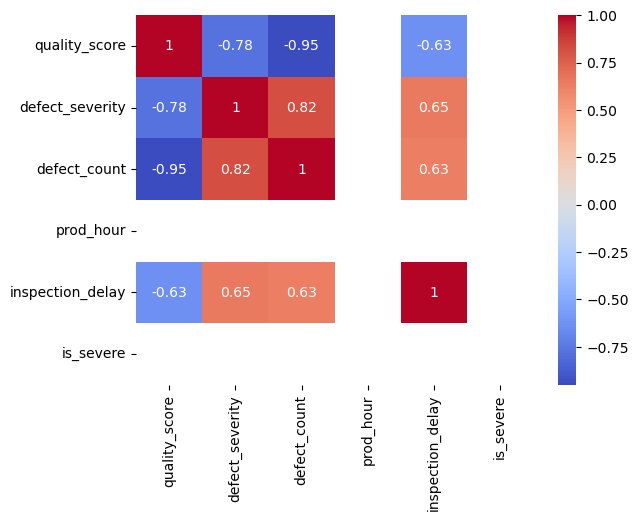

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
mask = np.triu(numeric_df.corr())


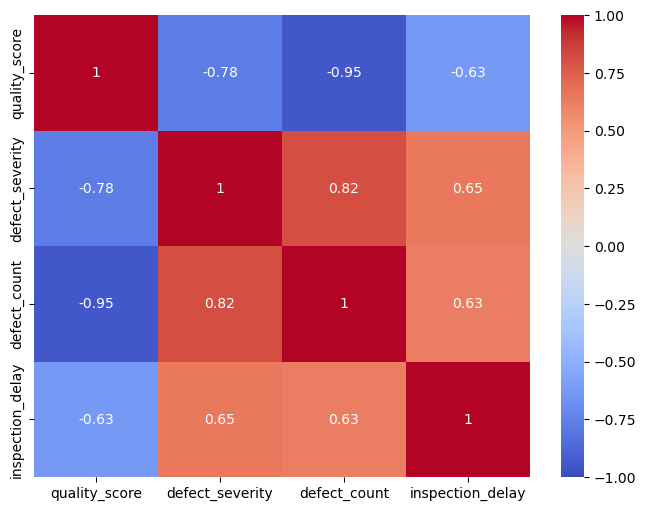

In [847]:
numeric_df = df.select_dtypes(include=np.number)

# Remove prod_hour
numeric_df = numeric_df.drop(columns=['prod_hour','is_severe'])
corr = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()


In [ ]:
rework_by_defect = df[df['rework_required']=='Yes'].groupby('defect_type')['defect_count'].sum().sort_values(ascending=False)
rework_by_defect 

Series([], Name: defect_count, dtype: int64)

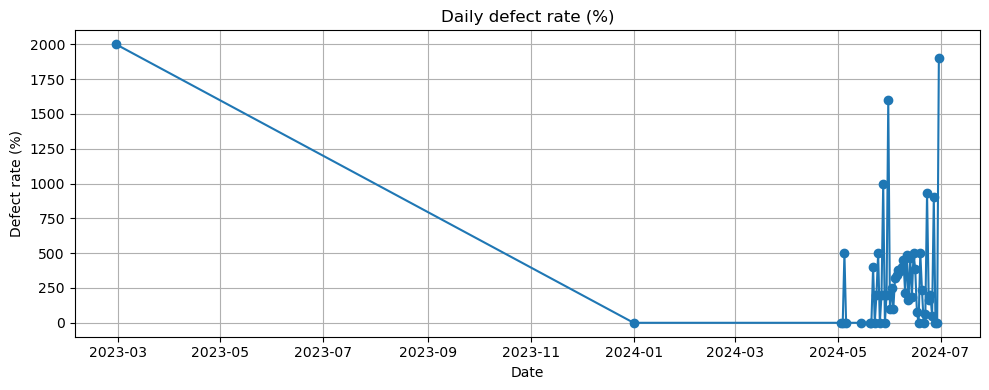

In [ ]:
# Aggregate per day
if 'prod_date' in df.columns:
    daily = df.groupby('prod_date').agg(
        total_units = ('batch_id','count'),
        total_defects = ('defect_count','sum') if 'defect_count' in df.columns else ('defect_type','count')
    ).reset_index()
    daily['defect_rate_pct'] = 100 * daily['total_defects'] / daily['total_units']

    # plot defect rate trend
    plt.figure(figsize=(10,4))
    plt.plot(daily['prod_date'], daily['defect_rate_pct'], marker='o')
    plt.title('Daily defect rate (%)')
    plt.xlabel('Date')
    plt.ylabel('Defect rate (%)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No production date column parsed; skip time-series plot.")


### Defect analysis by machine / operator / shift

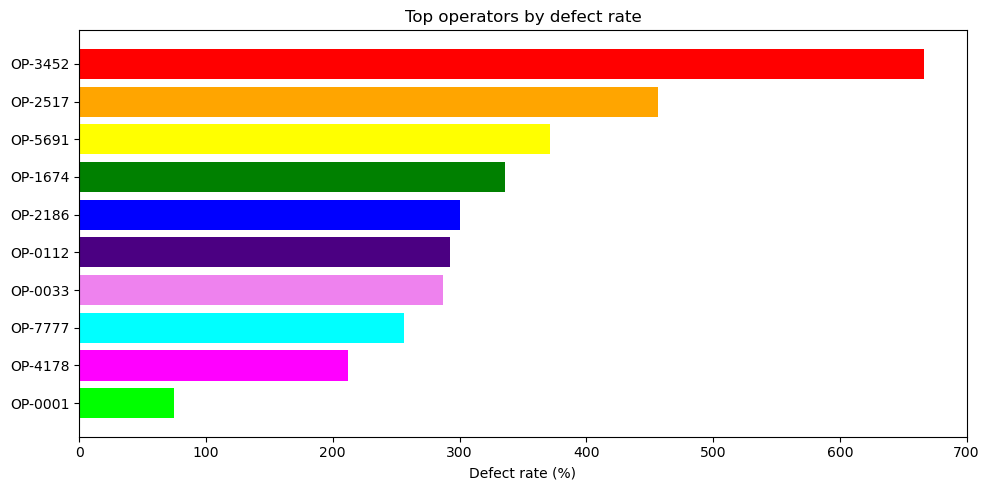

In [843]:
# Example: defects by operator
if 'operator_id' in df.columns:
    by_op = df.groupby('operator_id').agg(total = ('batch_id','count'),defects = ('defect_count','sum') if 'defect_count' in df.columns else ('defect_type','count'))
    by_op['defect_rate_pct'] = 100 * by_op['defects'] / by_op['total']
    by_op = by_op.sort_values('defect_rate_pct', ascending=False).head(20)
    
    plt.figure(figsize=(10,5))
    plt.barh(by_op.index.astype(str), by_op['defect_rate_pct'], color=['Red', 'Orange', 'Yellow', 'Green', 'Blue', 'Indigo', 'Violet', 'Cyan', 'Magenta', 'Lime', 'Pink', 'Teal', 'Lavender', 'Brown', 'Beige', 'Maroon', 'Olive', 'Coral', 'Navy', 'Grey'  ])
    plt.gca().invert_yaxis()
    plt.xlabel('Defect rate (%)')
    plt.title('Top operators by defect rate')
    plt.tight_layout()
    plt.show()
else:
    print("No operator_id column.")


### Pareto of defect types (frequency)

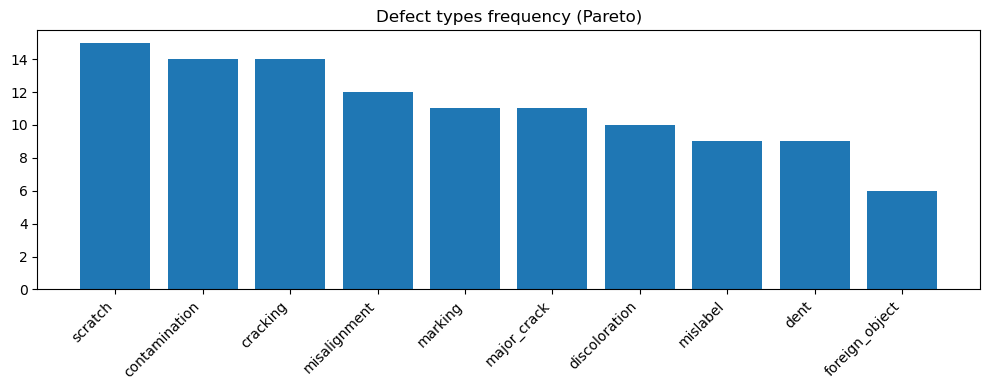

,defect_type,count,cum_pct
0,scratch,15,13.513514
1,contamination,14,26.126126
2,cracking,14,38.738739
3,misalignment,12,49.549550
4,marking,11,59.459459
5,major_crack,11,69.369369
6,discoloration,10,78.378378
7,mislabel,9,86.486486
8,dent,9,94.594595
9,foreign_object,6,100.000000


In [ ]:
if 'defect_type' in df.columns:
    counts = df['defect_type'].value_counts().reset_index()
    counts.columns = ['defect_type','count']
    counts['cum_pct'] = 100 * counts['count'].cumsum() / counts['count'].sum()

    plt.figure(figsize=(10,4))
    plt.bar(counts['defect_type'], counts['count'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Defect types frequency (Pareto)')
    plt.tight_layout()
    plt.show()

    display(counts.head(10))   # top 10 defect types
else:
    print("No defect_type column.")


### Process parameter stability: boxplots

<Figure size 1200x500 with 0 Axes>

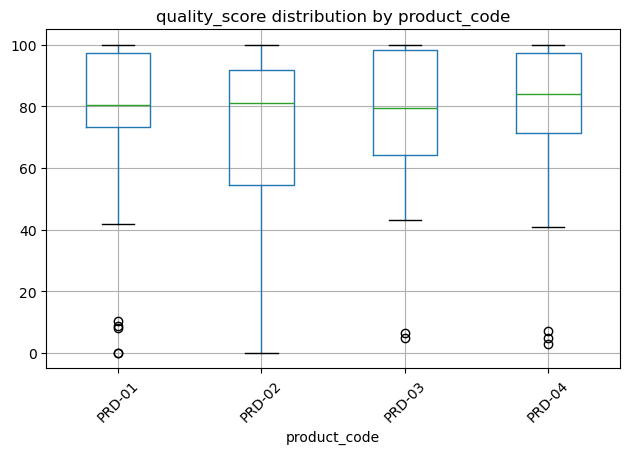

In [ ]:
# Example for numeric process parameter like 'quality_score' or 'defect_severity'
num_col = 'quality_score' if 'quality_score' in df.columns else ('defect_severity' if 'defect_severity' in df.columns else None)
if num_col:
    # boxplot by machine if machine-like column exists
    group_col = 'product_code' if 'product_code' in df.columns else ('operator_id' if 'operator_id' in df.columns else None)
    if group_col:
        plt.figure(figsize=(12,5))
        df.boxplot(column=num_col, by=group_col, rot=45)
        plt.title(f'{num_col} distribution by {group_col}')
        plt.suptitle('')
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6,4))
        df[num_col].plot(kind='box')
        plt.title(num_col)
        plt.tight_layout()
        plt.show()
else:
    print("No numeric process column (quality_score or defect_severity) found.")


### Correlation heatmap

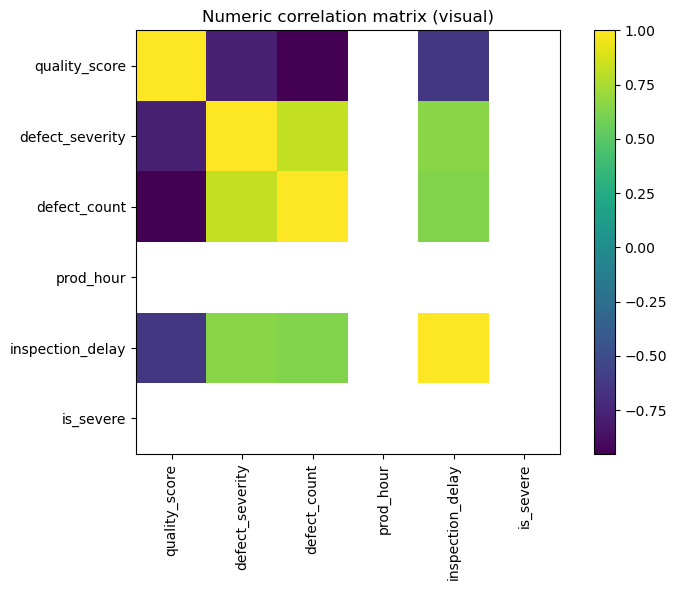

,quality_score,defect_severity,defect_count,prod_hour,inspection_delay,is_severe
quality_score,1.000000,-0.779439,-0.951030,NaN,-0.631072,NaN
defect_severity,-0.779439,1.000000,0.817196,NaN,0.649667,NaN
defect_count,-0.951030,0.817196,1.000000,NaN,0.630623,NaN
prod_hour,NaN,NaN,NaN,NaN,NaN,NaN
inspection_delay,-0.631072,0.649667,0.630623,NaN,1.000000,NaN
is_severe,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# correlation
num_df = df.select_dtypes(include=[np.number])
if not num_df.empty:
    corr = num_df.corr()
    plt.figure(figsize=(8,6))
    plt.imshow(corr, interpolation='nearest')
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title('Numeric correlation matrix (visual)')
    plt.tight_layout()
    plt.show()
    display(corr)
else:
    print("No numeric columns to correlate.")


### Shift / hourly patterns

### Simple control chart (mean ± 3σ) for a metric

Basic statistical process control to flag out-of-control batches.
(Points outside ±3σ are out-of-control — inspect those batches.)

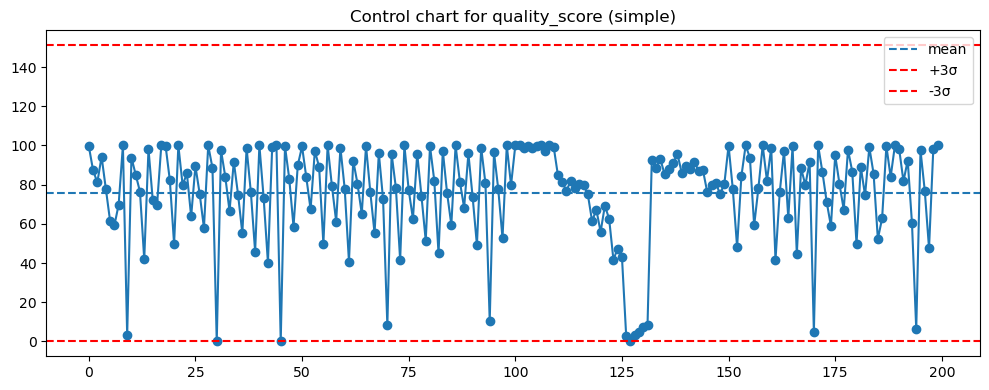

In [ ]:
# control chart for numeric metric (quality_score)
if 'quality_score' in df.columns:
    metric = df['quality_score'].dropna()
    mean = metric.mean()
    std = metric.std()
    upper = mean + 3*std
    lower = mean - 3*std

    plt.figure(figsize=(10,4))
    plt.plot(metric.values, marker='o')
    plt.axhline(mean, linestyle='--', label='mean')
    plt.axhline(upper, color='r', linestyle='--', label='+3σ')
    plt.axhline(lower, color='r', linestyle='--', label='-3σ')
    plt.title('Control chart for quality_score (simple)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No quality_score column for control chart.")


### Key KPI's (EDA Summary)

In [ ]:
total_defects = df['defect_count'].sum()
avg_quality_score = df['quality_score'].mean()
rework_rate = (df['rework_required'].eq('Yes').sum() / len(df)) * 100
unique_inspectors = df['inspector_id'].nunique()

print(f"Total Defects: {total_defects}")
print(f"Average Quality Score: {avg_quality_score:.2f}")
print(f"Rework Rate: {rework_rate:.2f}%")
print(f"Unique Inspectors: {unique_inspectors}")

Total Defects: 645
Average Quality Score: 75.70
Rework Rate: 0.00%
Unique Inspectors: 27


### Preparing CSV file for Dashboard

In [ ]:
df_clean = df.fillna(0)  # fill missing numbers with 0
if 'defect_count' in df_clean.columns:
    df_clean['has_defect'] = (df_clean['defect_count'] > 0).astype(int)  # binary defect flag

# 3️⃣ Export cleaned version for Tableau (same folder)
df_clean.to_csv("manufacturing_datasets_for_tableau.csv", index=False)
print("Cleaned dataset saved as manufacturing_cleaned_for_tableau.csv")

Cleaned dataset saved as manufacturing_cleaned_for_tableau.csv


In [ ]:
df_manufacturing

,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,defect_severity,defect_count,rework_required,comments,factory_location
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01T15:22:17,INS-2231,99.7,NaN,NaN,0,False,No issues detected. Batch meets all quality be...,Factory-E1
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02T09:18:43,INS-9052,87.4,NaN,NaN,0,False,Perfect batch. No defects observed.,Factory-Y7
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04T00:43:11,INS-0342,81.1,scratch,1.0,1,False,Minor scratch detected but within tolerance.,Factory-Z3
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03T16:08:29,INS-5961,94.3,NaN,NaN,0,False,Batch exceeded benchmarks.,Factory-X0
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04T08:42:14,INS-9052,77.8,marking,2.0,2,False,Spot marking observed. No rework required.,Factory-G9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,T8452-20240624,2024-06-24,PRD-04,morning,OP-2186,INSP-0046,2024-06-24T08:55:00,INS-2517,97.5,NaN,NaN,0,False,No defects found during inspection.,Factory-Y7
196,U3917-20240624,2024-06-24,PRD-01,afternoon,OP-7777,INSP-0047,2024-06-24T15:23:00,INS-0112,76.9,dent,2.0,1,False,"Minor dent found, batch passes.",Factory-X0
197,V8093-20240625,2024-06-25,PRD-03,night,OP-1674,INSP-0048,2024-06-26T00:03:00,INS-3452,47.5,contamination,3.0,6,True,Batch failed due to contamination.,Factory-G9
198,W5076-20240625,2024-06-25,PRD-02,afternoon,OP-5691,INSP-0049,2024-06-25T14:57:00,INS-5648,98.2,NaN,NaN,0,False,Batch PRD-02 meets all benchmarks.,Factory-E1


In [ ]:
df_clean

,batch_id,production_date,product_code,shift,operator_id,inspection_id,inspection_date,inspector_id,quality_score,defect_type,...,defect_count,rework_required,comments,factory_location,prod_date,prod_hour,prod_weekday,inspection_delay,is_severe,has_defect
0,A1234-20240601,2024-06-01,PRD-02,afternoon,OP-5691,INSP-0001,2024-06-01 15:22:17,INS-2231,99.7,0,...,0,False,No issues detected. Batch meets all quality be...,Factory-E1,2024-06-01,0,Saturday,0,0,0
1,B0876-20240602,2024-06-02,PRD-03,morning,OP-1674,INSP-0002,2024-06-02 09:18:43,INS-9052,87.4,0,...,0,False,Perfect batch. No defects observed.,Factory-Y7,2024-06-02,0,Sunday,0,0,0
2,C4218-20240603,2024-06-03,PRD-01,night,OP-2517,INSP-0003,2024-06-04 00:43:11,INS-0342,81.1,scratch,...,1,False,Minor scratch detected but within tolerance.,Factory-Z3,2024-06-03,0,Monday,1,0,1
3,D3127-20240603,2024-06-03,PRD-04,afternoon,OP-0033,INSP-0004,2024-06-03 16:08:29,INS-5961,94.3,0,...,0,False,Batch exceeded benchmarks.,Factory-X0,2024-06-03,0,Monday,0,0,0
4,E2098-20240604,2024-06-04,PRD-02,morning,OP-5691,INSP-0005,2024-06-04 08:42:14,INS-9052,77.8,marking,...,2,False,Spot marking observed. No rework required.,Factory-G9,2024-06-04,0,Tuesday,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,T8452-20240624,2024-06-24,PRD-04,morning,OP-2186,INSP-0046,2024-06-24 08:55:00,INS-2517,97.5,0,...,0,False,No defects found during inspection.,Factory-Y7,2024-06-24,0,Monday,0,0,0
196,U3917-20240624,2024-06-24,PRD-01,afternoon,OP-7777,INSP-0047,2024-06-24 15:23:00,INS-0112,76.9,dent,...,1,False,"Minor dent found, batch passes.",Factory-X0,2024-06-24,0,Monday,0,0,1
197,V8093-20240625,2024-06-25,PRD-03,night,OP-1674,INSP-0048,2024-06-26 00:03:00,INS-3452,47.5,contamination,...,6,True,Batch failed due to contamination.,Factory-G9,2024-06-25,0,Tuesday,1,0,1
198,W5076-20240625,2024-06-25,PRD-02,afternoon,OP-5691,INSP-0049,2024-06-25 14:57:00,INS-5648,98.2,0,...,0,False,Batch PRD-02 meets all benchmarks.,Factory-E1,2024-06-25,0,Tuesday,0,0,0


In [ ]:
df_clean.columns.tolist()

['batch_id',
 'production_date',
 'product_code',
 'shift',
 'operator_id',
 'inspection_id',
 'inspection_date',
 'inspector_id',
 'quality_score',
 'defect_type',
 'defect_severity',
 'defect_count',
 'rework_required',
 'comments',
 'factory_location',
 'prod_date',
 'prod_hour',
 'prod_weekday',
 'inspection_delay',
 'is_severe',
 'has_defect']

# Implementing Machine Learning

SMART QUALITY DEFECT PREDICTION

Import library

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

### Model 1 Predict Defect Likelihood

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Load data
df = df_clean.copy()   # Or use: pd.read_csv("your_clean_file.csv")

# Correlation check for numeric leakage
print("\n🔍 Checking numeric correlations with 'has_defect':")
corr = df.corr(numeric_only=True)['has_defect'].sort_values(ascending=False)
print(corr)

#  Keep only PRE-INSPECTION features (data known before inspection)
valid_features = [
    'shift',
    'operator_id',
    'product_code',
    'factory_location',
    'prod_weekday',
    'prod_hour'
]

target = 'has_defect'
X = df[valid_features]
y = df[target]

#  Encode categorical columns
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

#  Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
model.fit(X_train, y_train)

#  Evaluate model
y_pred = model.predict(X_test)
print("\n Model Evaluation:")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print(classification_report(y_test, y_pred))

# Predict probabilities for all batches
df['predicted_defect_prob'] = model.predict_proba(X_encoded)[:, 1]

# Export Tableau-ready predictions
output_file = "defect_predictions_no_leakage.csv"
df.to_csv(output_file, index=False)
print(f"\n Saved predictions to {output_file}")

# Feature importance (process factors only)
importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Key factors influencing defect probability:")
print(importance)



🔍 Checking numeric correlations with 'has_defect':
has_defect          1.000000
defect_severity     0.843833
rework_required     0.586199
defect_count        0.576124
inspection_delay    0.439019
quality_score      -0.694826
prod_hour                NaN
is_severe                NaN
Name: has_defect, dtype: float64

 Model Evaluation:
Accuracy: 77.5 %
              precision    recall  f1-score   support

           0       0.59      0.83      0.69        12
           1       0.91      0.75      0.82        28

    accuracy                           0.78        40
   macro avg       0.75      0.79      0.76        40
weighted avg       0.82      0.78      0.78        40


 Saved predictions to defect_predictions_no_leakage.csv

 Key factors influencing defect probability:
            Feature  Importance
0             shift    0.253393
1       operator_id    0.209917
4      prod_weekday    0.202708
3  factory_location    0.195595
2      product_code    0.138386
5         prod_hour    0

### MODEL 2 Predicting Defect Severity

In [ ]:

# Model 2: Severity Prediction

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Filter rows with actual defects
df_severe = df_clean[df_clean['has_defect'] == 1].copy()

# Create binary severity target (1 = severe defect)
df_severe['is_severe'] = (df_severe['defect_severity'] >= 2).astype(int)

# Check distribution
print("Value counts for is_severe:")
print(df_severe['is_severe'].value_counts())

# Choose features (you can adjust these)
features = [
    'quality_score', 'defect_count', 'prod_hour',
    'inspection_delay', 'shift', 'factory_location'
]

# Encode categorical columns
df_encoded = pd.get_dummies(df_severe[features], drop_first=True)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    df_encoded, df_severe['is_severe'], test_size=0.2, random_state=42
)

#  Train Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate performance
y_pred = model.predict(X_test)
print("\n Severity Model Performance:")
print(classification_report(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

y_pred = model.predict(X_test)
print("\n Model Evaluation:")
print(classification_report(y_test, y_pred))

# Save predictions for Tableau visualization
# df_severe.loc[X_test.index, 'predicted_severe'] = y_pred
# df_severe[['inspection_id', 'defect_severity', 'is_severe', 'predicted_severe']].to_csv(
#     "severity_predictions_for_tableau.csv", index=False
# )

#print("\n File saved: severity_predictions_for_tableau.csv")



Value counts for is_severe:
is_severe
1    88
0    23
Name: count, dtype: int64

 Severity Model Performance:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.89      0.89      0.89        18

    accuracy                           0.83        23
   macro avg       0.74      0.74      0.74        23
weighted avg       0.83      0.83      0.83        23

Accuracy: 82.61 %
Confusion Matrix:
 [[ 3  2]
 [ 2 16]]

 Model Evaluation:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.89      0.89      0.89        18

    accuracy                           0.83        23
   macro avg       0.74      0.74      0.74        23
weighted avg       0.83      0.83      0.83        23



### Model 3: Quality Score Prediction (Regression Model)


In [848]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare the dataset
df_quality = df_clean.copy()

# Drop rows with missing quality_score (if any)
df_quality = df_quality.dropna(subset=['quality_score'])

# Choose features that may influence quality
features = [
    'defect_count', 'defect_severity', 'inspection_delay',
    'prod_hour', 'shift', 'operator_id', 'factory_location'
]

# Encode categorical features
df_encoded = pd.get_dummies(df_quality[features], drop_first=True)

# Define target variable
target = df_quality['quality_score']

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    df_encoded, target, test_size=0.2, random_state=42
)

# Train the model
model = RandomForestRegressor(random_state=42, n_estimators=200)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

#  Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n Quality Score Model Performance:")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R²   (Model Fit): {r2:.3f}")

# Save predictions for Tableau
# df_quality.loc[X_test.index, 'predicted_quality_score'] = y_pred
# df_quality[['inspection_id', 'quality_score', 'predicted_quality_score']].to_csv(
#     "quality_predictions_for_tableau.csv", index=False
# )

# print("\n File saved: quality_predictions_for_tableau.csv")



 Quality Score Model Performance:
MAE  (Mean Absolute Error): 4.88
RMSE (Root Mean Squared Error): 6.48
R²   (Model Fit): 0.952


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare the dataset
df_quality = df_clean.copy()

# Drop rows with missing quality_score (if any)
df_quality = df_quality.dropna(subset=['quality_score'])

# Choose features that may influence quality
features = [
    'defect_count', 'defect_severity', 'inspection_delay',
    'prod_hour', 'shift', 'operator_id', 'factory_location'
]

# Encode categorical features
df_encoded = pd.get_dummies(df_quality[features], drop_first=True)

# Define target variable
target = df_quality['quality_score']

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    df_encoded, target, test_size=0.2, random_state=42
)

# Train the model
quality_model = RandomForestRegressor(random_state=42, n_estimators=200)
quality_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = quality_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("\n Quality Score Model Performance (Test Set):")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R²   (Model Fit): {r2:.3f}")

# Predict for all rows
df_quality['predicted_quality_score'] = quality_model.predict(df_encoded)

# Save predictions for Tableau
output_file = "quality_predictions_for_tableau.csv"
df_quality[['inspection_id', 'quality_score', 'predicted_quality_score']].to_csv(output_file, index=False)
print(f"\n File saved: {output_file}")



 Quality Score Model Performance (Test Set):
MAE  (Mean Absolute Error): 4.88
RMSE (Root Mean Squared Error): 6.48
R²   (Model Fit): 0.952

 File saved: quality_predictions_for_tableau.csv


In [ ]:
# export_combined_predictions.py
import pandas as pd
import numpy as np
from datetime import datetime
import os




# ---------- CONFIG ----------
main_path = "manufacturing_datasets_for_tableau.csv"   # your cleaned main dataset
m1_path = "predicted_defect_risk_tableau.csv"             # model 1: defect probability
m2_path = "severity_predictions_for_tableau.csv"               # model 2: severity (numeric or label)
m3_path = "quality_predictions_for_tableau.csv"                 # model 3: predicted quality score
output_folder = "."  # save in same folder; change if needed
join_key = "inspection_id"  # change to inspection_id if that's your key
# ----------------------------


# 1) Load files
print("Loading data...")
df_main = pd.read_csv(main_path, parse_dates=['production_date','inspection_date'], infer_datetime_format=True)
m1 = pd.read_csv(m1_path)
m2 = pd.read_csv(m2_path)
m3 = pd.read_csv(m3_path)

print("Shapes:", df_main.shape, m1.shape, m2.shape, m3.shape)

# 2) Optional: rename model columns to avoid conflicts (safe-guard)
m1 = m1.rename(columns={c:c if c==join_key else f"m1_{c}" for c in m1.columns})
m2 = m2.rename(columns={c:c if c==join_key else f"m2_{c}" for c in m2.columns})
m3 = m3.rename(columns={c:c if c==join_key else f"m3_{c}" for c in m3.columns})

m2 = m2.groupby(join_key, as_index=False).mean()  # or .first() if categorical ---------

# If models already use consistent names, you can skip/adjust above

# 3) Merge datasets (left join main -> models)
df = df_main.merge(m1, on=join_key, how='left')
df = df.merge(m2, on=join_key, how='left')
df = df.merge(m3, on=join_key, how='left')

print("After merge shape:", df.shape)

# 4) Create useful derived fields
# - high risk flag (example threshold 0.7)
if 'm1_pred_defect_prob' in df.columns:
    df['pred_defect_prob'] = df['m1_pred_defect_prob']  # safe alias
    df['predicted_high_risk'] = np.where(df['pred_defect_prob'] >= 0.7, 1, 0)
else:
    # attempt to find any m1 probability column
    for c in df.columns:
        if c.lower().startswith('m1_pred') and 'prob' in c.lower():
            df['pred_defect_prob'] = df[c]
            df['predicted_high_risk'] = np.where(df[c] >= 0.7, 1, 0)
            break

# - severity label normalization (if numeric -> bucket)
if 'm2_pred_defect_severity' in df.columns:
    if np.issubdtype(df['m2_pred_defect_severity'].dtype, np.number):
        # example buckets (tune as needed)
        bins = [-1, 1.5, 2.5, 3.5, 10]
        labels = ['Low','Medium','High','Critical']
        df['pred_severity_label'] = pd.cut(df['m2_pred_defect_severity'], bins=bins, labels=labels)
    else:
        df['pred_severity_label'] = df['m2_pred_defect_severity'].astype(str)

# - error metrics if actual available
if 'quality_score' in df.columns and 'm3_pred_quality_score' in df.columns:
    df['pred_error_quality'] = df['m3_pred_quality_score'] - df['quality_score']
    df['abs_error_quality'] = df['pred_error_quality'].abs()

# 5) Quick validation summary
print("\nValidation summary:")
total_rows = len(df)
missing_m1 = df['m1_pred_defect_prob'].isna().sum() if 'm1_pred_defect_prob' in df.columns else 'n/a'
missing_m2 = df['m2_pred_defect_severity'].isna().sum() if 'm2_pred_defect_severity' in df.columns else 'n/a'
missing_m3 = df['m3_pred_quality_score'].isna().sum() if 'm3_pred_quality_score' in df.columns else 'n/a'
print(f"Total rows: {total_rows}")
print(f"Missing M1 preds: {missing_m1}")
print(f"Missing M2 preds: {missing_m2}")
print(f"Missing M3 preds: {missing_m3}")

# 6) Compute quick performance metrics (if actuals present)
metrics = {}
if 'pred_defect_prob' in df.columns and 'defect_count' in df.columns:
    # create actual binary whether batch had defect (has_defect)
    df['has_defect_actual'] = np.where(df['defect_count']>0, 1, 0)
    # simple classification at 0.5 threshold
    df['pred_has_defect_05'] = np.where(df['pred_defect_prob']>=0.5, 1, 0)
    tp = ((df['pred_has_defect_05']==1) & (df['has_defect_actual']==1)).sum()
    tn = ((df['pred_has_defect_05']==0) & (df['has_defect_actual']==0)).sum()
    fp = ((df['pred_has_defect_05']==1) & (df['has_defect_actual']==0)).sum()
    fn = ((df['pred_has_defect_05']==0) & (df['has_defect_actual']==1)).sum()
    accuracy = (tp+tn)/ (tp+tn+fp+fn) if (tp+tn+fp+fn)>0 else np.nan
    metrics['defect_pred_accuracy_0.5'] = accuracy

if 'm3_pred_quality_score' in df.columns and 'quality_score' in df.columns:
    rmse = np.sqrt((df['pred_error_quality']**2).mean())
    mae = df['abs_error_quality'].mean()
    metrics['quality_rmse'] = rmse
    metrics['quality_mae'] = mae

print("\nComputed metrics (if available):")
for k,v in metrics.items():
    print(f" - {k}: {v}")

# 7) Prepare final export columns (choose a sensible subset)
# Keep main columns + model columns + derived columns
keep_cols = [
    join_key, 'production_date', 'inspection_date', 'product_code', 'shift',
    'operator_id', 'inspector_id', 'factory_location',
    'defect_count', 'quality_score', 'defect_type', 'defect_severity',
    # model columns (if present)
    'm1_pred_defect_prob', 'pred_defect_prob', 'predicted_high_risk',
    'm2_pred_defect_severity', 'pred_severity_label',
    'm3_pred_quality_score', 'pred_error_quality', 'abs_error_quality',
    # simple KPI/flags
    'has_defect_actual'
]

# Keep only existing columns from the list
keep_cols = [c for c in keep_cols if c in df.columns]
df_export = df[keep_cols].copy()

# 8) Save CSV with timestamp
ts = datetime.now().strftime("%Y%m%d_%H%M")
out_name = f"combined_for_tableau_{ts}.csv"
out_path = os.path.join(output_folder, out_name)
df_export.to_csv(out_path, index=False)
print("\nSaved combined CSV to:", out_path)


Loading data...
Shapes: (200, 21) (200, 22) (111, 4) (200, 3)
After merge shape: (800, 47)

Validation summary:
Total rows: 800
Missing M1 preds: n/a
Missing M2 preds: n/a
Missing M3 preds: n/a

Computed metrics (if available):
 - defect_pred_accuracy_0.5: 0.445

Saved combined CSV to: ./combined_for_tableau_20251114_0450.csv


/var/folders/tj/8m4f2hl545d85f9bhjg24z500000gn/T/ipykernel_55528/3094386906.py:22: FutureWarning:

The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.



In [ ]:
import pandas as pd

# === 1️⃣ Load both model output files ===
print("Loading model files...")
df_defect = pd.read_csv("defect_predictions_no_leakage.csv")
df_severe = pd.read_csv("severity_predictions_for_tableau.csv")

print("Shapes:", df_defect.shape, df_severe.shape)

# === 2️⃣ Inspect columns to confirm available names ===
print("\nDefect Prediction Columns:")
print(df_defect.columns.tolist())

print("\nSeverity Prediction Columns:")
print(df_severe.columns.tolist())

# === 3️⃣ Standardize key names if needed ===
# (Some files might use 'inspection_id' or 'Inspection_ID' or 'inspectionid')
for df in [df_defect, df_severe]:
    df.columns = df.columns.str.strip().str.lower()  # remove spaces and lowercase

# Ensure we have inspection_id column
if "inspection_id" not in df_defect.columns:
    # Try to auto-detect the right column
    possible_keys = [c for c in df_defect.columns if "insp" in c]
    if possible_keys:
        df_defect.rename(columns={possible_keys[0]: "inspection_id"}, inplace=True)

if "inspection_id" not in df_severe.columns:
    possible_keys = [c for c in df_severe.columns if "insp" in c]
    if possible_keys:
        df_severe.rename(columns={possible_keys[0]: "inspection_id"}, inplace=True)

# === 4️⃣ Select and rename important columns safely ===
# Defect prediction
defect_cols = ["inspection_id"]
if "predicted_defect_prob" in df_defect.columns:
    defect_cols.append("predicted_defect_prob")
if "has_defect" in df_defect.columns:
    defect_cols.append("has_defect")

# Severity prediction
severe_cols = ["inspection_id"]
if "severe_probability" in df_severe.columns:
    severe_cols.append("severe_probability")
if "is_severe" in df_severe.columns:
    severe_cols.append("is_severe")
if "predicted_severe" in df_severe.columns and "is_severe" not in severe_cols:
    severe_cols.append("predicted_severe")

# === 5️⃣ Merge safely on inspection_id ===
df_combined = pd.merge(
    df_defect[defect_cols],
    df_severe[severe_cols],
    on="inspection_id",
    how="left"
)

# === 6️⃣ Handle missing severity probabilities for non-defect inspections ===
df_combined["severe_probability"] = df_combined.get("severe_probability", pd.Series(0, index=df_combined.index)).fillna(0)
df_combined["is_severe"] = df_combined.get("is_severe", pd.Series(0, index=df_combined.index)).fillna(0)

# === 7️⃣ Save combined dataset ===
output_file = "combined_risk_tableau.csv"
df_combined.to_csv(output_file, index=False)

print(f"\n✅ Combined dataset saved successfully: {output_file}")
print(f"Rows: {len(df_combined)}, Columns: {len(df_combined.columns)}")
print(df_combined.head())


Loading model files...
Shapes: (200, 22) (111, 4)

Defect Prediction Columns:
['batch_id', 'production_date', 'product_code', 'shift', 'operator_id', 'inspection_id', 'inspection_date', 'inspector_id', 'quality_score', 'defect_type', 'defect_severity', 'defect_count', 'rework_required', 'comments', 'factory_location', 'prod_date', 'prod_hour', 'prod_weekday', 'inspection_delay', 'is_severe', 'has_defect', 'predicted_defect_prob']

Severity Prediction Columns:
['inspection_id', 'defect_severity', 'is_severe', 'predicted_severe']

✅ Combined dataset saved successfully: combined_risk_tableau.csv
Rows: 266, Columns: 5
  inspection_id  predicted_defect_prob  has_defect  is_severe  \
0     INSP-0001                  0.125           0        0.0   
1     INSP-0002                  0.065           0        0.0   
2     INSP-0003                  0.925           1        0.0   
3     INSP-0003                  0.925           1        1.0   
4     INSP-0004                  0.030           0   